Line centre: 104329.68 cm^-1   (95.85 nm)
At 300 K, 1.0 atm:  Doppler HWHM = 0.1223 cm^-1,  Lorentz HWHM = 0.0991 cm^-1
Area under Gaussian  : 1.0
Area under Lorentzian: 0.9997
Area under Voigt     : 0.9997


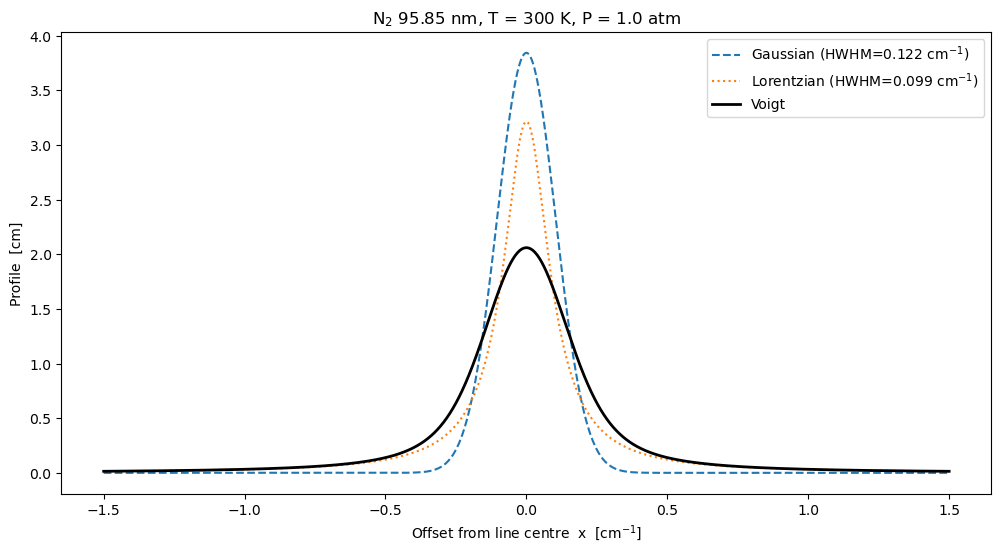

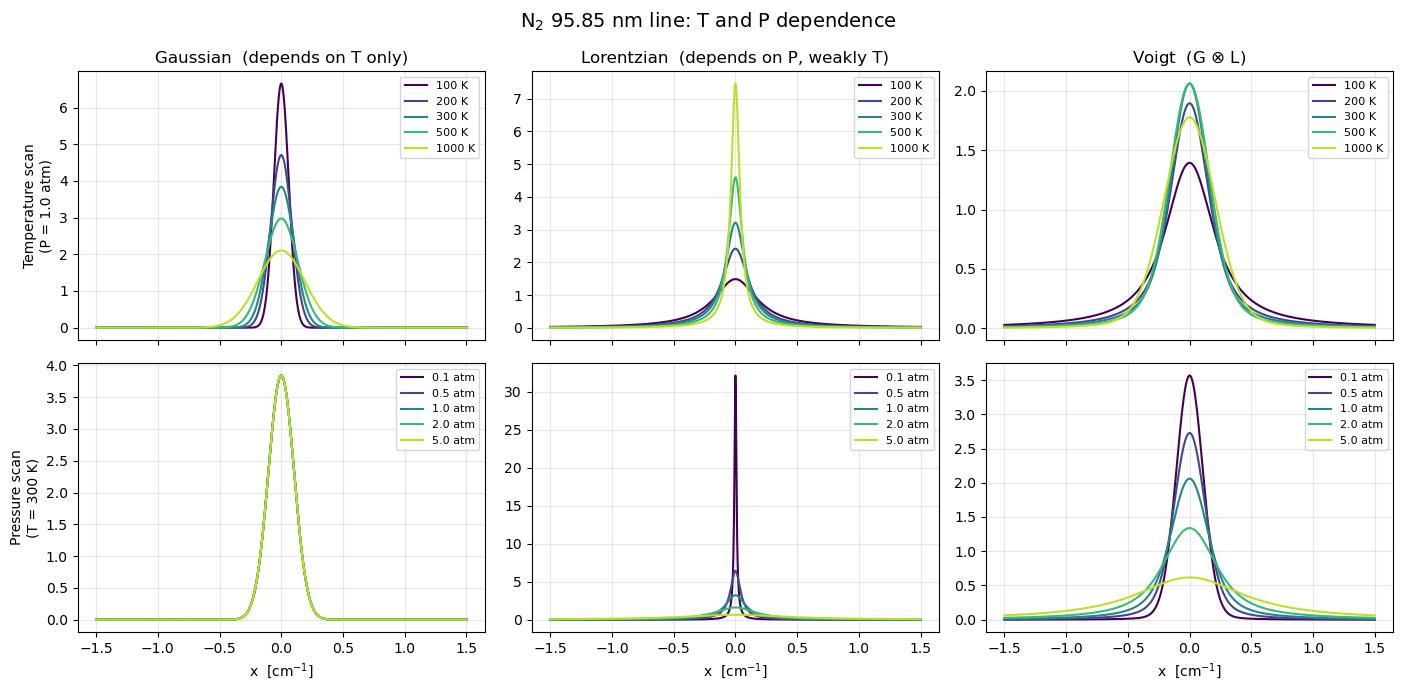

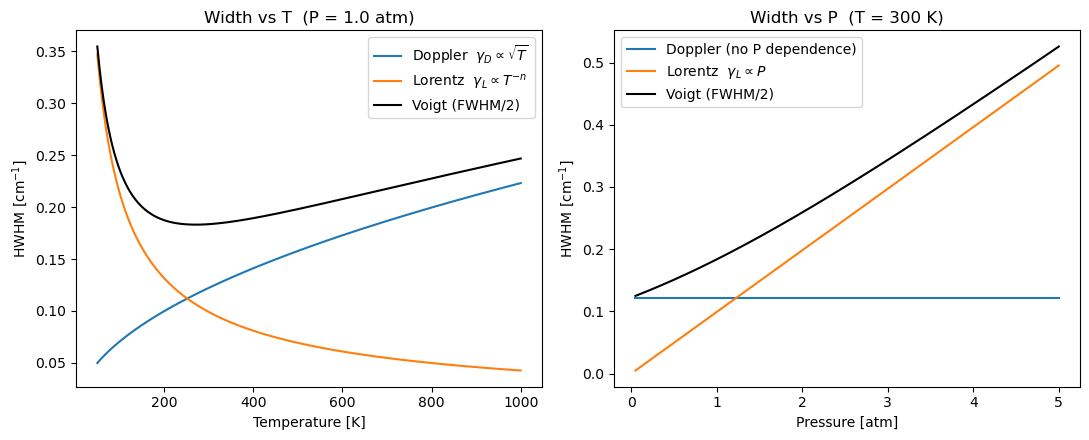

In [3]:
"""
Voigt line profile vs. temperature and pressure
Transition: N2 at 95.85 nm (12.94 eV)

EQUATIONS USED  (x = wavenumber offset from line centre, in cm^-1)
--------------------------------------------------------------------
(1) Line centre         nu0 = 1 / lambda0                  [cm^-1]

(2) Doppler (Gaussian) HWHM   (depends on T only)
        gamma_D = (nu0 / c) * sqrt( 2 ln2 * k T / m )

(3) Gaussian profile
        G(x) = sqrt(ln2/pi) / gamma_D * exp( -ln2 * (x/gamma_D)^2 )

(4) Pressure (Lorentzian) HWHM   (depends on P and T)
        gamma_L = gamma_L0 * (P / P0) * (T0 / T)^n

(5) Lorentzian profile
        L(x) = (gamma_L / pi) / ( x^2 + gamma_L^2 )

(6) Voigt profile = convolution of G and L
        V(x) = Re[ w(z) ] / ( sigma * sqrt(2 pi) )
        z    = ( x + i*gamma_L ) / ( sigma * sqrt(2) )
        sigma = gamma_D / sqrt(2 ln2)           (Gaussian std. deviation)
    where w(z) is the Faddeeva function (scipy.special.wofz).

(7) Approximate Voigt FWHM (Olivero & Longbothum 1977)
        f_V = 0.5346 f_L + sqrt( 0.2166 f_L^2 + f_G^2 )
    with f_L = 2 gamma_L and f_G = 2 gamma_D.

CONVENTION WARNING: every width in this script is a HWHM (half width at
half maximum), NOT a FWHM and NOT the 1/e width.
All three profiles are normalised so that  integral( profile dx ) = 1.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import wofz

# ----------------------------------------------------------------------
# 1. Constants (SI) and line parameters
# ----------------------------------------------------------------------
k_B = 1.380649e-23          # Boltzmann constant [J/K]
c = 2.99792458e8            # speed of light [m/s]
amu = 1.66053907e-27        # atomic mass unit [kg]
m_N2 = 28.0134 * amu        # mass of an N2 molecule [kg]

lambda0_nm = 95.85                       # transition wavelength [nm]
nu0 = 1.0 / (lambda0_nm * 1e-7)          # line centre [cm^-1]   (Eq. 1)

# Pressure-broadening parameters.
# !! ASSUMED PLACEHOLDER VALUES !! HITRAN does not tabulate EUV electronic
# transitions of N2, so replace these with values from your own source.
gamma_L0 = 0.10     # Lorentz HWHM at T0 and P0 [cm^-1]
T0 = 296.0          # reference temperature [K]
P0 = 1.0            # reference pressure [atm]
n_T = 0.7           # temperature exponent of the Lorentz width


# ----------------------------------------------------------------------
# 2. Functions (one per equation)
# ----------------------------------------------------------------------
def doppler_hwhm(T):
    """Eq. (2): Doppler HWHM in cm^-1."""
    return nu0 / c * np.sqrt(2 * np.log(2) * k_B * T / m_N2)


def lorentz_hwhm(T, P):
    """Eq. (4): pressure-broadened Lorentz HWHM in cm^-1."""
    return gamma_L0 * (P / P0) * (T0 / T) ** n_T


def gaussian(x, gamma_D):
    """Eq. (3): normalised Gaussian."""
    return np.sqrt(np.log(2) / np.pi) / gamma_D * np.exp(-np.log(2) * (x / gamma_D) ** 2)


def lorentzian(x, gamma_L):
    """Eq. (5): normalised Lorentzian."""
    return (gamma_L / np.pi) / (x ** 2 + gamma_L ** 2)


def voigt(x, gamma_D, gamma_L):
    """Eq. (6): normalised Voigt profile via the Faddeeva function."""
    sigma = gamma_D / np.sqrt(2 * np.log(2))
    z = (x + 1j * gamma_L) / (sigma * np.sqrt(2))
    return wofz(z).real / (sigma * np.sqrt(2 * np.pi))


def voigt_fwhm(gamma_D, gamma_L):
    """Eq. (7): approximate Voigt FWHM in cm^-1."""
    f_G, f_L = 2 * gamma_D, 2 * gamma_L
    return 0.5346 * f_L + np.sqrt(0.2166 * f_L ** 2 + f_G ** 2)


# ----------------------------------------------------------------------
# 3. Sanity check: do the profiles integrate to 1?
#    The Lorentzian wings decay slowly, so we need a MUCH wider grid
#    than the one used for plotting, otherwise we lose ~ a few percent.
# ----------------------------------------------------------------------
trapz = getattr(np, "trapezoid", None) or np.trapz   # works on old & new NumPy

T_test, P_test = 300.0, 1.0
gD, gL = doppler_hwhm(T_test), lorentz_hwhm(T_test, P_test)
x_wide = np.linspace(-2000 * gD, 2000 * gD, 400001)
print(f"Line centre: {nu0:.2f} cm^-1   ({lambda0_nm} nm)")
print(f"At {T_test:.0f} K, {P_test} atm:  Doppler HWHM = {gD:.4f} cm^-1,"
      f"  Lorentz HWHM = {gL:.4f} cm^-1")
print("Area under Gaussian  :", round(trapz(gaussian(x_wide, gD), x_wide), 4))
print("Area under Lorentzian:", round(trapz(lorentzian(x_wide, gL), x_wide), 4))
print("Area under Voigt     :", round(trapz(voigt(x_wide, gD, gL), x_wide), 4))

# ----------------------------------------------------------------------
# 4. Plotting grid and the T and P values to scan
# ----------------------------------------------------------------------
x = np.linspace(-1.5, 1.5, 3001)             # offset from line centre [cm^-1]

T_list = [100, 200, 300, 500, 1000]          # K    (P fixed)
P_list = [0.1, 0.5, 1.0, 2.0, 5.0]           # atm  (T fixed)
T_fixed, P_fixed = 300.0, 1.0

# ----------------------------------------------------------------------
# 5. Figure 1: the three profiles at one (T, P)
# ----------------------------------------------------------------------
fig1, ax = plt.subplots(figsize=(12,6 ))
gD, gL = doppler_hwhm(T_fixed), lorentz_hwhm(T_fixed, P_fixed)
ax.plot(x, gaussian(x, gD), "--", label=f"Gaussian (HWHM={gD:.3f} cm$^{{-1}}$)")
ax.plot(x, lorentzian(x, gL), ":", label=f"Lorentzian (HWHM={gL:.3f} cm$^{{-1}}$)")
ax.plot(x, voigt(x, gD, gL), "k", lw=2, label="Voigt")
ax.set_xlabel("Offset from line centre  x  [cm$^{-1}$]")
ax.set_ylabel("Profile  [cm]")
ax.set_title(f"N$_2$ {lambda0_nm} nm, T = {T_fixed:.0f} K, P = {P_fixed} atm")
ax.legend()

# ----------------------------------------------------------------------
# 6. Figure 2: 2 x 3 grid
#    Row 1: vary T (P fixed)   |   Row 2: vary P (T fixed)
#    Columns: Gaussian, Lorentzian, Voigt
# ----------------------------------------------------------------------
fig2, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
colors = plt.cm.viridis(np.linspace(0, 0.9, 5))

for col, T in zip(colors, T_list):                       # row 1: temperature scan
    gD, gL = doppler_hwhm(T), lorentz_hwhm(T, P_fixed)
    axes[0, 0].plot(x, gaussian(x, gD), color=col, label=f"{T} K")
    axes[0, 1].plot(x, lorentzian(x, gL), color=col, label=f"{T} K")
    axes[0, 2].plot(x, voigt(x, gD, gL), color=col, label=f"{T} K")

for col, P in zip(colors, P_list):                       # row 2: pressure scan
    gD, gL = doppler_hwhm(T_fixed), lorentz_hwhm(T_fixed, P)
    axes[1, 0].plot(x, gaussian(x, gD), color=col, label=f"{P} atm")
    axes[1, 1].plot(x, lorentzian(x, gL), color=col, label=f"{P} atm")
    axes[1, 2].plot(x, voigt(x, gD, gL), color=col, label=f"{P} atm")

axes[0, 0].set_title("Gaussian  (depends on T only)")
axes[0, 1].set_title("Lorentzian  (depends on P, weakly T)")
axes[0, 2].set_title("Voigt  (G $\\otimes$ L)")
axes[0, 0].set_ylabel(f"Temperature scan\n(P = {P_fixed} atm)")
axes[1, 0].set_ylabel(f"Pressure scan\n(T = {T_fixed:.0f} K)")
for a in axes[1, :]:
    a.set_xlabel("x  [cm$^{-1}$]")
for a in axes.flat:
    a.legend(fontsize=8)
    a.grid(alpha=0.3)
fig2.suptitle(f"N$_2$ {lambda0_nm} nm line: T and P dependence", fontsize=14)
fig2.tight_layout()

# ----------------------------------------------------------------------
# 7. Figure 3: how the widths themselves scale with T and P
# ----------------------------------------------------------------------
T_arr = np.linspace(50, 1000, 200)
P_arr = np.linspace(0.05, 5, 200)

fig3, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.5))
a1.plot(T_arr, doppler_hwhm(T_arr), label="Doppler  $\\gamma_D \\propto \\sqrt{T}$")
a1.plot(T_arr, lorentz_hwhm(T_arr, P_fixed), label="Lorentz  $\\gamma_L \\propto T^{-n}$")
a1.plot(T_arr, voigt_fwhm(doppler_hwhm(T_arr), lorentz_hwhm(T_arr, P_fixed)) / 2,
        "k", label="Voigt (FWHM/2)")
a1.set_xlabel("Temperature [K]")
a1.set_ylabel("HWHM [cm$^{-1}$]")
a1.set_title(f"Width vs T  (P = {P_fixed} atm)")
a1.legend()

a2.plot(P_arr, doppler_hwhm(T_fixed) * np.ones_like(P_arr), label="Doppler (no P dependence)")
a2.plot(P_arr, lorentz_hwhm(T_fixed, P_arr), label="Lorentz  $\\gamma_L \\propto P$")
a2.plot(P_arr, voigt_fwhm(doppler_hwhm(T_fixed), lorentz_hwhm(T_fixed, P_arr)) / 2,
        "k", label="Voigt (FWHM/2)")
a2.set_xlabel("Pressure [atm]")
a2.set_ylabel("HWHM [cm$^{-1}$]")
a2.set_title(f"Width vs P  (T = {T_fixed:.0f} K)")
a2.legend()
fig3.tight_layout()

plt.show()

Line centre: 104329.68 cm^-1   (95.85 nm)
At 300 K, 1.0 atm:  Doppler HWHM = 0.1223 cm^-1,  Lorentz HWHM = 0.0991 cm^-1
Area under Gaussian  : 1.0
Area under Lorentzian: 0.9997
Area under Voigt     : 0.9997


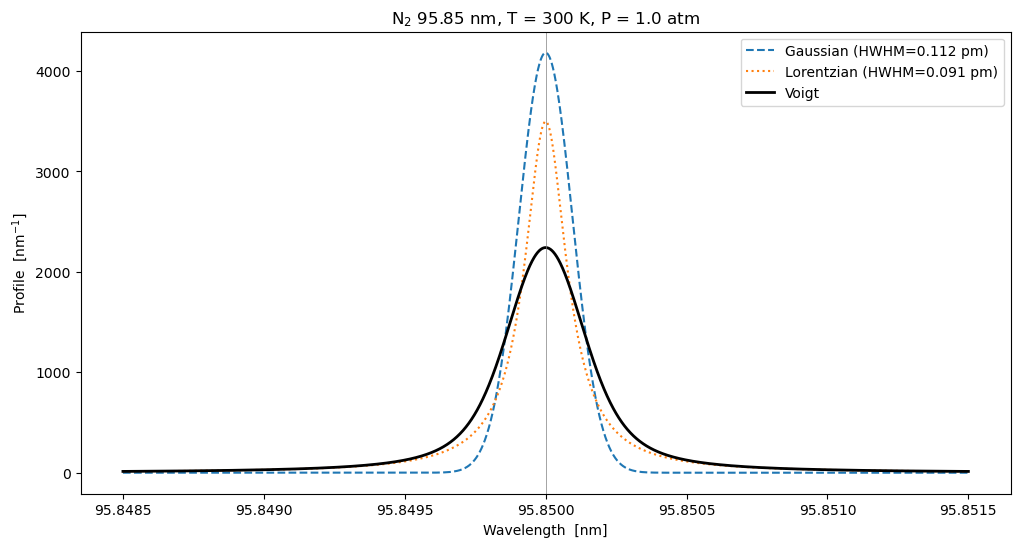

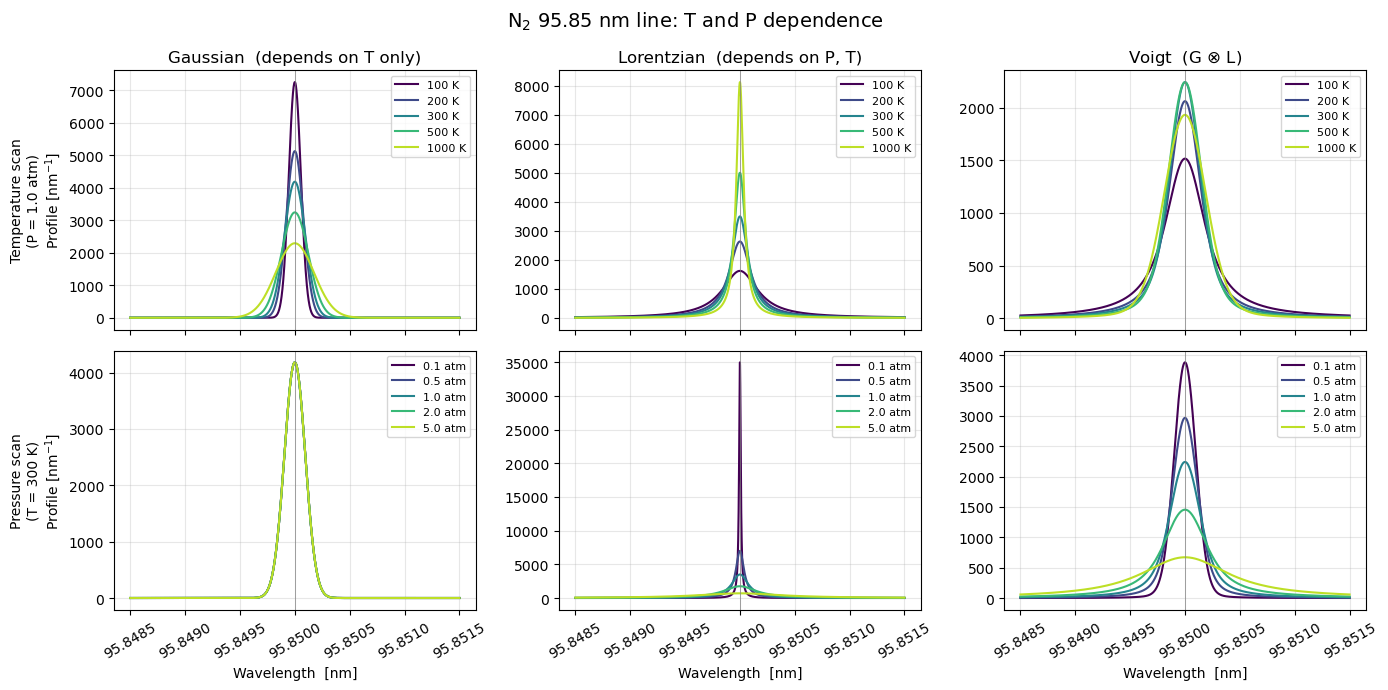

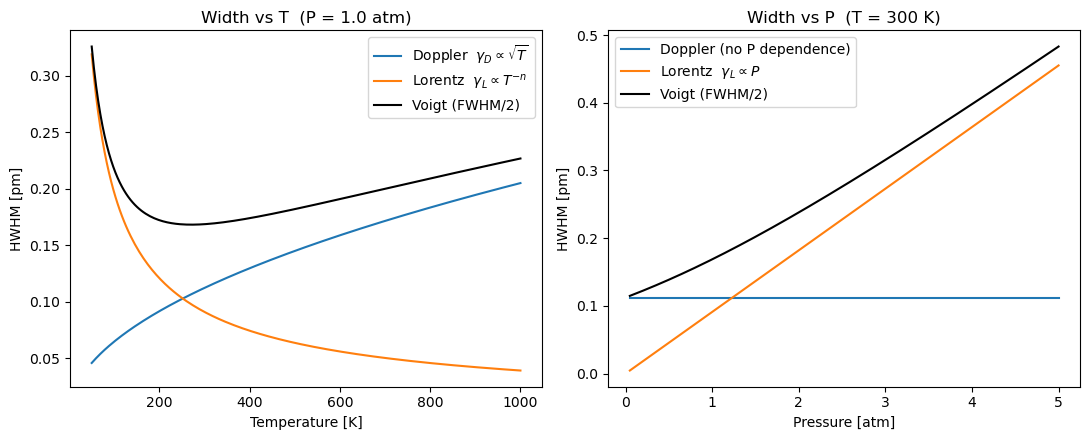

In [9]:
"""
Voigt line profile vs. temperature and pressure
Transition: N2 at 95.85 nm (12.94 eV)

EQUATIONS USED  (x = wavenumber offset from line centre, in cm^-1)
--------------------------------------------------------------------
(1) Line centre         nu0 = 1 / lambda0                  [cm^-1]

(2) Doppler (Gaussian) HWHM   (depends on T only)
        gamma_D = (nu0 / c) * sqrt( 2 ln2 * k T / m )

(3) Gaussian profile
        G(x) = sqrt(ln2/pi) / gamma_D * exp( -ln2 * (x/gamma_D)^2 )

(4) Pressure (Lorentzian) HWHM   (depends on P and T)
        gamma_L = gamma_L0 * (P / P0) * (T0 / T)^n

(5) Lorentzian profile
        L(x) = (gamma_L / pi) / ( x^2 + gamma_L^2 )

(6) Voigt profile = convolution of G and L
        V(x) = Re[ w(z) ] / ( sigma * sqrt(2 pi) )
        z    = ( x + i*gamma_L ) / ( sigma * sqrt(2) )
        sigma = gamma_D / sqrt(2 ln2)           (Gaussian std. deviation)
    where w(z) is the Faddeeva function (scipy.special.wofz).

(7) Approximate Voigt FWHM (Olivero & Longbothum 1977)
        f_V = 0.5346 f_L + sqrt( 0.2166 f_L^2 + f_G^2 )
    with f_L = 2 gamma_L and f_G = 2 gamma_D.

(8) Converting the x axis from wavenumber to wavelength
        lambda = 1e7 / (nu0 + x)                 [nm, with nu in cm^-1]
    A profile that integrates to 1 per cm^-1 must be multiplied by the
    Jacobian  |d nu / d lambda| = 1e7 / lambda^2  so that it integrates to 1
    per nm.  Width conversion near line centre:
        d_lambda = lambda0^2 * d_nu * 1e-7       [nm]

CONVENTION WARNING: every width in this script is a HWHM (half width at
half maximum), NOT a FWHM and NOT the 1/e width.
All three profiles are normalised so that  integral( profile dx ) = 1.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import wofz

# ----------------------------------------------------------------------
# 1. Constants (SI) and line parameters
# ----------------------------------------------------------------------
k_B = 1.380649e-23          # Boltzmann constant [J/K]
c = 2.99792458e8            # speed of light [m/s]
amu = 1.66053907e-27        # atomic mass unit [kg]
m_N2 = 28.0134 * amu        # mass of an N2 molecule [kg]

lambda0_nm = 95.85                       # transition wavelength [nm]
nu0 = 1.0 / (lambda0_nm * 1e-7)          # line centre [cm^-1]   (Eq. 1)

# Pressure-broadening parameters.
# !! ASSUMED PLACEHOLDER VALUES !! HITRAN does not tabulate EUV electronic
# transitions of N2, so replace these with values from your own source.
gamma_L0 = 0.10     # Lorentz HWHM at T0 and P0 [cm^-1]
T0 = 296.0          # reference temperature [K]
P0 = 1.0            # reference pressure [atm]
n_T = 0.7           # temperature exponent of the Lorentz width


# ----------------------------------------------------------------------
# 2. Functions (one per equation)
# ----------------------------------------------------------------------
def doppler_hwhm(T):
    """Eq. (2): Doppler HWHM in cm^-1."""
    return nu0 / c * np.sqrt(2 * np.log(2) * k_B * T / m_N2)


def lorentz_hwhm(T, P):
    """Eq. (4): pressure-broadened Lorentz HWHM in cm^-1."""
    return gamma_L0 * (P / P0) * (T0 / T) ** n_T


def gaussian(x, gamma_D):
    """Eq. (3): normalised Gaussian."""
    return np.sqrt(np.log(2) / np.pi) / gamma_D * np.exp(-np.log(2) * (x / gamma_D) ** 2)


def lorentzian(x, gamma_L):
    """Eq. (5): normalised Lorentzian."""
    return (gamma_L / np.pi) / (x ** 2 + gamma_L ** 2)


def voigt(x, gamma_D, gamma_L):
    """Eq. (6): normalised Voigt profile via the Faddeeva function."""
    sigma = gamma_D / np.sqrt(2 * np.log(2))
    z = (x + 1j * gamma_L) / (sigma * np.sqrt(2))
    return wofz(z).real / (sigma * np.sqrt(2 * np.pi))


def voigt_fwhm(gamma_D, gamma_L):
    """Eq. (7): approximate Voigt FWHM in cm^-1."""
    f_G, f_L = 2 * gamma_D, 2 * gamma_L
    return 0.5346 * f_L + np.sqrt(0.2166 * f_L ** 2 + f_G ** 2)


def jacobian(lam_nm):
    """Eq. (8): converts a profile per cm^-1 into a profile per nm."""
    return 1e7 / lam_nm ** 2


def width_to_pm(w_cm):
    """Eq. (8): convert a width in cm^-1 to picometres near lambda0."""
    return lambda0_nm ** 2 * w_cm * 1e-7 * 1e3


# ----------------------------------------------------------------------
# 3. Sanity check: do the profiles integrate to 1?
#    The Lorentzian wings decay slowly, so we need a MUCH wider grid
#    than the one used for plotting, otherwise we lose ~ a few percent.
# ----------------------------------------------------------------------
trapz = getattr(np, "trapezoid", None) or np.trapz   # works on old & new NumPy

T_test, P_test = 300.0, 1.0
gD, gL = doppler_hwhm(T_test), lorentz_hwhm(T_test, P_test)
x_wide = np.linspace(-2000 * gD, 2000 * gD, 400001)
print(f"Line centre: {nu0:.2f} cm^-1   ({lambda0_nm} nm)")
print(f"At {T_test:.0f} K, {P_test} atm:  Doppler HWHM = {gD:.4f} cm^-1,"
      f"  Lorentz HWHM = {gL:.4f} cm^-1")
print("Area under Gaussian  :", round(trapz(gaussian(x_wide, gD), x_wide), 4))
print("Area under Lorentzian:", round(trapz(lorentzian(x_wide, gL), x_wide), 4))
print("Area under Voigt     :", round(trapz(voigt(x_wide, gD, gL), x_wide), 4))

# ----------------------------------------------------------------------
# 4. Plotting grid and the T and P values to scan
# ----------------------------------------------------------------------
lam = np.linspace(lambda0_nm - 0.0015, lambda0_nm + 0.0015, 3001)   # wavelength [nm]
x = 1e7 / lam - nu0          # same points as an offset from line centre [cm^-1]
jac = jacobian(lam)          # per cm^-1  ->  per nm

T_list = [100, 200, 300, 500, 1000]          # K    (P fixed)
P_list = [0.1, 0.5, 1.0, 2.0, 5.0]           # atm  (T fixed)
T_fixed, P_fixed = 300.0, 1.0

# ----------------------------------------------------------------------
# 5. Figure 1: the three profiles at one (T, P)
# ----------------------------------------------------------------------
fig1, ax = plt.subplots(figsize=(12, 6))
gD, gL = doppler_hwhm(T_fixed), lorentz_hwhm(T_fixed, P_fixed)
ax.plot(lam, jac * gaussian(x, gD), "--", label=f"Gaussian (HWHM={width_to_pm(gD):.3f} pm)")
ax.plot(lam, jac * lorentzian(x, gL), ":", label=f"Lorentzian (HWHM={width_to_pm(gL):.3f} pm)")
ax.plot(lam, jac * voigt(x, gD, gL), "k", lw=2, label="Voigt")
ax.set_xlabel("Wavelength  [nm]")
ax.axvline(lambda0_nm, color="gray", lw=0.5)
ax.set_ylabel("Profile  [nm$^{-1}$]")
ax.set_title(f"N$_2$ {lambda0_nm} nm, T = {T_fixed:.0f} K, P = {P_fixed} atm")
ax.ticklabel_format(useOffset=False, axis="x", style="plain")
ax.legend()

# ----------------------------------------------------------------------
# 6. Figure 2: 2 x 3 grid
#    Row 1: vary T (P fixed)   |   Row 2: vary P (T fixed)
#    Columns: Gaussian, Lorentzian, Voigt
# ----------------------------------------------------------------------
fig2, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
colors = plt.cm.viridis(np.linspace(0, 0.9, 5))

for col, T in zip(colors, T_list):                       # row 1: temperature scan
    gD, gL = doppler_hwhm(T), lorentz_hwhm(T, P_fixed)
    axes[0, 0].plot(lam, jac * gaussian(x, gD), color=col, label=f"{T} K")
    axes[0, 1].plot(lam, jac * lorentzian(x, gL), color=col, label=f"{T} K")
    axes[0, 2].plot(lam, jac * voigt(x, gD, gL), color=col, label=f"{T} K")

for col, P in zip(colors, P_list):                       # row 2: pressure scan
    gD, gL = doppler_hwhm(T_fixed), lorentz_hwhm(T_fixed, P)
    axes[1, 0].plot(lam, jac * gaussian(x, gD), color=col, label=f"{P} atm")
    axes[1, 1].plot(lam, jac * lorentzian(x, gL), color=col, label=f"{P} atm")
    axes[1, 2].plot(lam, jac * voigt(x, gD, gL), color=col, label=f"{P} atm")

axes[0, 0].set_title("Gaussian  (depends on T only)")
axes[0, 1].set_title("Lorentzian  (depends on P, T)")
axes[0, 2].set_title("Voigt  (G $\\otimes$ L)")
axes[0, 0].set_ylabel(f"Temperature scan\n(P = {P_fixed} atm)")
axes[1, 0].set_ylabel(f"Pressure scan\n(T = {T_fixed:.0f} K)")
for a in axes[1, :]:
    a.set_xlabel("Wavelength  [nm]")
for a in axes[:, 0]:
    a.set_ylabel(a.get_ylabel() + "\nProfile [nm$^{-1}$]")
for a in axes.flat:
    a.ticklabel_format(useOffset=False, axis="x", style="plain")
    a.tick_params(axis="x", labelrotation=30)
    a.axvline(lambda0_nm, color="gray", lw=0.5)
    a.legend(fontsize=8)
    a.grid(alpha=0.3)
fig2.suptitle(f"N$_2$ {lambda0_nm} nm line: T and P dependence", fontsize=14)
fig2.tight_layout()

# ----------------------------------------------------------------------
# 7. Figure 3: how the widths themselves scale with T and P
# ----------------------------------------------------------------------
T_arr = np.linspace(50, 1000, 200)
P_arr = np.linspace(0.05, 5, 200)

fig3, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.5))
a1.plot(T_arr, width_to_pm(doppler_hwhm(T_arr)), label="Doppler  $\\gamma_D \\propto \\sqrt{T}$")
a1.plot(T_arr, width_to_pm(lorentz_hwhm(T_arr, P_fixed)), label="Lorentz  $\\gamma_L \\propto T^{-n}$")
a1.plot(T_arr, width_to_pm(voigt_fwhm(doppler_hwhm(T_arr), lorentz_hwhm(T_arr, P_fixed)) / 2),
        "k", label="Voigt (FWHM/2)")
a1.set_xlabel("Temperature [K]")
a1.set_ylabel("HWHM [pm]")
a1.set_title(f"Width vs T  (P = {P_fixed} atm)")
a1.legend()

a2.plot(P_arr, width_to_pm(doppler_hwhm(T_fixed)) * np.ones_like(P_arr), label="Doppler (no P dependence)")
a2.plot(P_arr, width_to_pm(lorentz_hwhm(T_fixed, P_arr)), label="Lorentz  $\\gamma_L \\propto P$")
a2.plot(P_arr, width_to_pm(voigt_fwhm(doppler_hwhm(T_fixed), lorentz_hwhm(T_fixed, P_arr)) / 2),
        "k", label="Voigt (FWHM/2)")
a2.set_xlabel("Pressure [atm]")
a2.set_ylabel("HWHM [pm]")
a2.set_title(f"Width vs P  (T = {T_fixed:.0f} K)")
a2.legend()
fig3.tight_layout()

fig1.savefig("voigt_single_condition.png", dpi=300, bbox_inches="tight")
fig2.savefig("voigt_T_P_grid.png", dpi=300, bbox_inches="tight")
fig3.savefig("voigt_widths_vs_T_P.png", dpi=300, bbox_inches="tight")

plt.show()

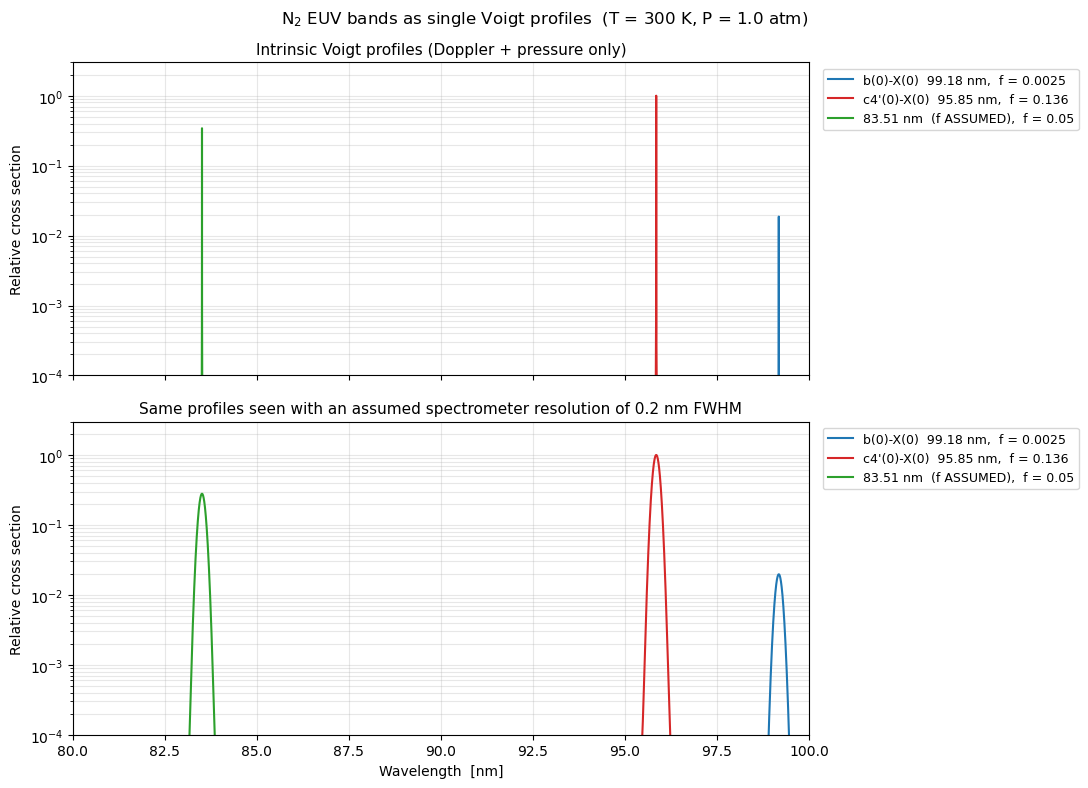

In [7]:
"""
Three N2 EUV bands as Voigt profiles on ONE plot, 80-100 nm
(99.18 nm, 95.85 nm, 83.51 nm), scaled by literature band f-values.

EQUATIONS (x = wavenumber offset from line centre, cm^-1; all widths HWHM)
--------------------------------------------------------------------------------
(1) Line centre      nu0 = 1e7 / lambda0_nm                              [cm^-1]
(2) Doppler HWHM     gamma_D = (nu0/c) * sqrt(2 ln2 k T / m)             [cm^-1]
(3) Pressure HWHM    gamma_L = gamma_L0 * (P/P0) * (T0/T)^n              [cm^-1]
(4) Instrument HWHM  gamma_I = 0.5 * FWHM_inst_nm * 1e7 / lambda0^2      [cm^-1]
    (a Gaussian instrument function folds into the Gaussian part:
        gamma_G = sqrt(gamma_D^2 + gamma_I^2) )
(5) Voigt            V(x) = Re[w(z)] / (sigma*sqrt(2 pi)),
                     z = (x + i*gamma_L)/(sigma*sqrt(2)),
                     sigma = gamma_G / sqrt(2 ln2)
(6) Line strength    S = (pi e^2 / (m_e c^2)) * f = 8.85e-13 * f      [cm^2 cm^-1]
(7) Cross section    sigma_abs(x) = S * V(x)                                [cm^2]
(8) Wavelength axis  lambda = 1e7 / (nu0 + x)                                [nm]
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import wofz

k_B, c, amu = 1.380649e-23, 2.99792458e8, 1.66053907e-27
m_N2 = 28.0134 * amu
S_PER_F = 8.8525e-13                              # cm^2 cm^-1 per unit f

# ---------------------------------------------------------------- band data
# f_value = band oscillator strength (rotationless / band-integrated)
lines = [
    # b(0)-X(0): Stark et al., JCP 123, 214303 (2005), Table I: band f ~ 2.5e-3
    {"name": "b(0)-X(0)  99.18 nm",  "lam0": 99.18, "f": 2.5e-3, "color": "tab:blue"},
    # c4'(0)-X(0): Stark et al., ApJ 531, 321 (2000): band f = 0.136 +/- 0.020
    {"name": "c4'(0)-X(0)  95.85 nm", "lam0": 95.85, "f": 0.136,  "color": "tab:red"},
    # 83.51 nm: NO verified value found -> ASSUMED placeholder (order of magnitude).
    # Replace with the Chan et al. (1993) / Wu & Judge (2006) value.
    {"name": "83.51 nm  (f ASSUMED)", "lam0": 83.51, "f": 5e-2,   "color": "tab:green"},
]

# ------------------------------------------------------------- conditions
T, P = 300.0, 1.0                                  # K, atm
gamma_L0, T0, P0, n_T = 0.10, 296.0, 1.0, 0.7      # ASSUMED pressure broadening
INSTRUMENT_FWHM_NM = 0.2                           # ASSUMED spectrometer resolution


# --------------------------------------------------------------- functions
def doppler_hwhm(nu0, T):
    return nu0 / c * np.sqrt(2 * np.log(2) * k_B * T / m_N2)

def lorentz_hwhm(T, P):
    return gamma_L0 * (P / P0) * (T0 / T) ** n_T

def voigt(x, gamma_G, gamma_L):
    sigma = gamma_G / np.sqrt(2 * np.log(2))
    z = (x + 1j * gamma_L) / (sigma * np.sqrt(2))
    return wofz(z).real / (sigma * np.sqrt(2 * np.pi))

def cross_section(lam, line, inst_fwhm_nm):
    nu0 = 1e7 / line["lam0"]
    x = 1e7 / lam - nu0                                       # Eq. (8) inverted
    gamma_I = 0.5 * inst_fwhm_nm * 1e7 / line["lam0"] ** 2    # Eq. (4)
    gamma_G = np.sqrt(doppler_hwhm(nu0, T) ** 2 + gamma_I ** 2)
    return S_PER_F * line["f"] * voigt(x, gamma_G, lorentz_hwhm(T, P))


# -------------------------------------------------- wavelength grid (80-100 nm)
# very dense right at each line (they are ~1e-4 nm wide), coarse elsewhere
pieces = [np.linspace(80, 100, 4001)]
for ln in lines:
    pieces.append(np.linspace(ln["lam0"] - 0.0015, ln["lam0"] + 0.0015, 3001))
    pieces.append(np.linspace(ln["lam0"] - 1.5, ln["lam0"] + 1.5, 6001))
lam = np.unique(np.concatenate(pieces))

# ------------------------------------------------------------------- plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

for ax, inst, title in [
    (ax1, 0.0, "Intrinsic Voigt profiles (Doppler + pressure only)"),
    (ax2, INSTRUMENT_FWHM_NM,
     f"Same profiles seen with an assumed spectrometer resolution of {INSTRUMENT_FWHM_NM} nm FWHM"),
]:
    curves = [cross_section(lam, ln, inst) for ln in lines]
    norm = max(cv.max() for cv in curves)                    # relative scale
    for ln, cv in zip(lines, curves):
        ax.plot(lam, cv / norm, color=ln["color"], lw=1.5,
                label=f"{ln['name']},  f = {ln['f']:g}")
    ax.set_yscale("log")
    ax.set_ylim(1e-4, 3)
    ax.set_ylabel("Relative cross section")
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.3, which="both")
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9)

ax2.set_xlim(80, 100)
ax2.set_xlabel("Wavelength  [nm]")
fig.suptitle(f"N$_2$ EUV bands as single Voigt profiles  (T = {T:.0f} K, P = {P} atm)")
fig.tight_layout()
fig.savefig("voigt_three_N2_lines_80_100nm.png", dpi=300, bbox_inches="tight")
plt.show()